In [1]:
# I would play a bit with the concept of value, simple and continously compound return and how they stack up
# together over a stock index such as the S&P 500

# load all required folders
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import sys
import os
sys.path.append(os.path.abspath("../"))

from src.utils import *

In [2]:
# load the overall S&P 500 values over the last year

snp500_all_year_values = get_snp_500_values('1y')

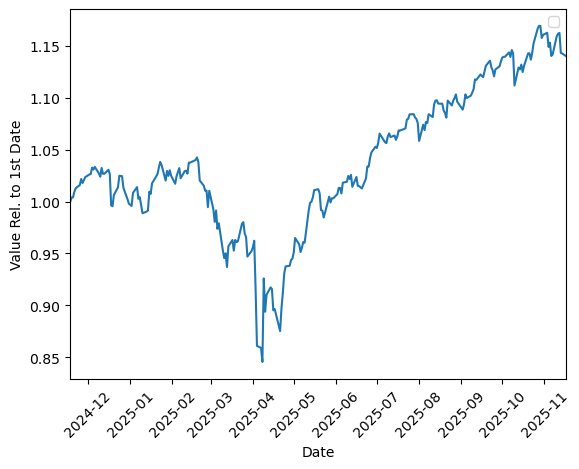

In [3]:
# change to % by dividing by the first value and mult by 100

snp500_all_year_normalized = snp500_all_year_values.copy()

snp500_all_year_normalized.iloc[:] = snp500_all_year_normalized.iloc[:] / snp500_all_year_values.iloc[0]

# plot the values over the year
x, y = snp500_all_year_normalized.index.to_numpy(), snp500_all_year_normalized['^GSPC'].to_numpy()
fig, ax = plt.subplots()
ax.plot(x, y)
ax.set_xlabel('Date')
ax.set_ylabel('Value Rel. to 1st Date')
ax.set_xlim([snp500_all_year_normalized.index[0], snp500_all_year_normalized.index[-1]])
ax.legend([])
plt.xticks(rotation=45)
plt.show()
plt.close()

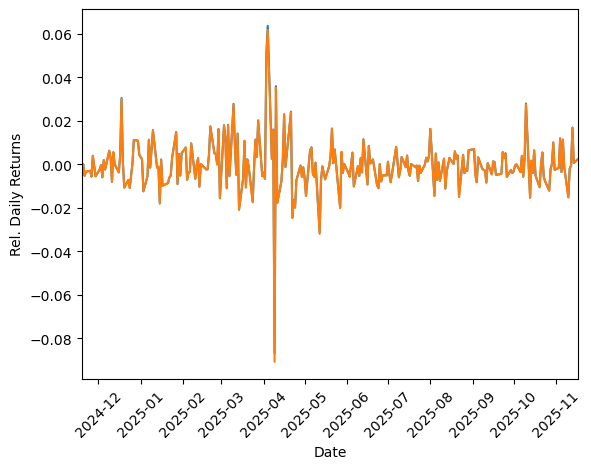

Avg. Abs. Rel. Diff: 0.0036509971035696216


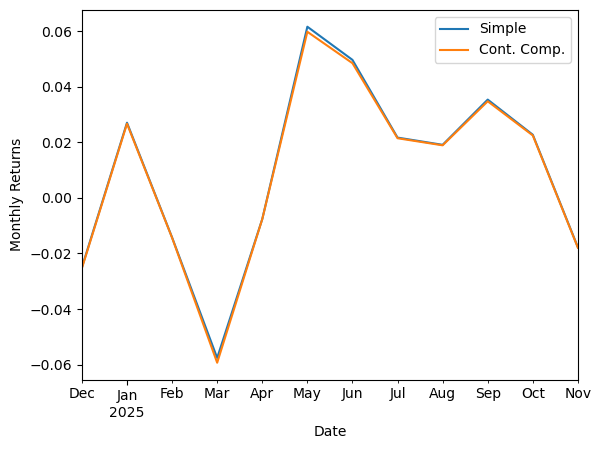

Avg. Abs. Rel. Diff: 0.014928018923511891


In [22]:
# plot the daily simple and continously compound returns on the same figure, see if they're approx the same

fig, ax = plt.subplots()

simple_return = (y[:-1]-y[1:])/y[1:]
cont_compound_return = np.log(y[:-1]/y[1:])

ax.plot(x[1:], simple_return, label='Simple')
ax.plot(x[1:], cont_compound_return, label='Cont. Compound')
ax.set_xlabel('Date')
ax.set_ylabel('Rel. Daily Returns')
ax.set_xlim([x[1], x[-1]])
plt.xticks(rotation=45)
plt.show()
plt.close()

# print how well the simple return predicts the more mathematically robust cont. compound one in the daily scale
print("Avg. Abs. Rel. Diff:", np.abs((cont_compound_return-simple_return)/cont_compound_return).mean())

# do same for monthly

monthly_simple_returns = snp500_all_year_normalized.resample('ME').last().pct_change().iloc[1:]
monthly_simple_returns.rename(columns={'^GSPC': 'Simple'}, inplace=True)
monthly_cont_compount_returns = snp500_all_year_normalized.resample('ME').last().apply(lambda x: np.log(x)).diff().iloc[1:]
monthly_cont_compount_returns.rename(columns={'^GSPC': 'Cont. Comp.'}, inplace=True)
monthly_returns = pd.concat([monthly_simple_returns, monthly_cont_compount_returns], axis=1)
monthly_returns.columns.name = None

monthly_returns.plot()
plt.ylabel('Monthly Returns')
plt.show()

print("Avg. Abs. Rel. Diff:", np.abs(((monthly_returns['Simple'] - monthly_returns['Cont. Comp.'])/monthly_returns['Cont. Comp.']).to_numpy()).mean())

In [ ]:
# check the distribution of daily returns in the last 10 years
